#### start cropping for cell-level

In [ ]:
import cv2
import os
import shutil
import numpy as np

# ================= CONFIGURATION =================
# 1. PATHS
IMG_DIR = r"C:\Users\Rowan\Documents\Rowan\Clean images\10-12-2024"
# RF_LABELS_DIR = "modified_data_1/valid/labels"           # Ground Truth (Defects)
YOLO_LABELS_DIR = "cell_detect_level_clean\predict\labels" # Detected Cells (candidates)
BASE_OUT = "dataset_cropped_cells_clean_result"                       # Output folder

# 2. CLASS NAMES (Must match your data.yaml ID order)
# Important: Class 0 is usually 'examined' or 'healthy'
CLASS_NAMES = [
    'healthy',          # ID 0 (Default if no defect found)
    # 'micro_crack',      # ID 1
    # 'crack',            # ID 2
    # 'low_cell',         # ID 3
    # 'isolated_area',    # ID 4
    # 'contamination',    # ID 5
    # 'other_error',      # ID 6
    # 'ShortCircuitString', # ID 7
    # 'break'             # ID 8
]

IOU_THRESHOLD = 0.3  # How much overlap is needed to call it a defect?

# ================= HELPER FUNCTIONS =================
def load_yolo(txt_path):
    """Loads YOLO labels from a txt file."""
    boxes = []
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                boxes.append(parts)
    return boxes

def yolo_to_xyxy(box, img_w, img_h):
    """Converts YOLO (x_center, y_center, w, h) to (x1, y1, x2, y2)."""
    xc, yc, w, h = box
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    # Clip to image boundaries
    return [max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)]

def compute_iou(boxA, boxB):
    """Calculates Intersection over Union (IoU) between two boxes."""
    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Compute the area of intersection rectangle
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # Compute the area of both rectangles
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Compute IoU
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

# ================= MAIN LOOP =================
# 1. Create Output Directories
if os.path.exists(BASE_OUT):
    shutil.rmtree(BASE_OUT)

for name in CLASS_NAMES:
    os.makedirs(os.path.join(BASE_OUT, name), exist_ok=True)

print(f"🚀 Starting processing...")
count = 0

# 2. Iterate through images
for img_name in os.listdir(IMG_DIR):
    if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue

    img_path = os.path.join(IMG_DIR, img_name)
    class_folder =

        # SAVE
        # Naming: OriginalImage_CellIndex.jpg
        save_filename = f"{os.path.splitext(img_name)[0]}_cell_{i}.jpg"
        save_path = os.path.join(BASE_OUT, class_folder, save_filename)
        cv2.imwrite(save_path, crop)
        count += 1

print(f"✅ Done! Processed {count} cell crops.")
print(f"📁 Results saved in: {BASE_OUT}")

🚀 Starting processing...
cell_detect_level_clean\predict\labels\DSC_3043.txt
cell_detect_level_clean\predict\labels\DSC_3103.txt
cell_detect_level_clean\predict\labels\DSC_3164.txt
cell_detect_level_clean\predict\labels\DSC_3174.txt
cell_detect_level_clean\predict\labels\DSC_3185.txt
cell_detect_level_clean\predict\labels\DSC_3195.txt
cell_detect_level_clean\predict\labels\DSC_3216.txt
cell_detect_level_clean\predict\labels\DSC_3227.txt
cell_detect_level_clean\predict\labels\DSC_3237.txt
cell_detect_level_clean\predict\labels\DSC_3248.txt
cell_detect_level_clean\predict\labels\DSC_3258.txt
cell_detect_level_clean\predict\labels\DSC_3268.txt
cell_detect_level_clean\predict\labels\DSC_3318.txt
cell_detect_level_clean\predict\labels\DSC_3329.txt
cell_detect_level_clean\predict\labels\DSC_3339.txt
cell_detect_level_clean\predict\labels\DSC_3349.txt
cell_detect_level_clean\predict\labels\DSC_3359.txt
cell_detect_level_clean\predict\labels\DSC_3369.txt
cell_detect_level_clean\predict\labels\

##### Analysze cropped cells brightness and shape....

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_image(image_path):
    # 1. Load Image
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not load image.")
        return

    # Convert to Grayscale (simplifies analysis)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ==========================================================
    # ANALYSIS 1: CRACK DETECTION (Geometry)
    # ==========================================================
    # Use Bilateral Filter: smooths textures but keeps sharp edges (cracks)
    # d=9, sigmaColor=75, sigmaSpace=75 are standard starting values
    filtered = cv2.bilateralFilter(gray, 9, 75, 75)

    # Canny Edge Detection
    # Thresholds (30, 150) determine how "strong" a line must be to count
    edges = cv2.Canny(filtered, 30, 150)

    # Morphological Closing: connects broken crack lines
    kernel = np.ones((3,3), np.uint8)
    closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Find Contours (to filter out tiny noise)
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    crack_mask = np.zeros_like(gray)
    min_crack_length = 50  # Ignore tiny specks (noise)

    for cnt in contours:
        if cv2.arcLength(cnt, True) > min_crack_length:
            cv2.drawContours(crack_mask, [cnt], -1, (255), thickness=2)

    # ==========================================================
    # ANALYSIS 2: LOCAL BRIGHTNESS ANOMALIES (Spots/Shadows)
    # ==========================================================
    # "Adaptive Thresholding" ignores global lightness.
    # It calculates the mean brightness of a 21x21 block around the pixel.
    # If the pixel is C (10) units darker than the mean, it's flagged.
    
    local_dark_spots = cv2.adaptiveThreshold(
        gray, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, # Invert so dark spots become white
        blockSize=21,          # Size of local area (must be odd)
        C=10                   # Sensitivity (Lower = detects more subtle changes)
    )

    # Filter out noise from the brightness mask using Median Blur
    local_dark_spots = cv2.medianBlur(local_dark_spots, 5)

    # ==========================================================
    # VISUALIZATION
    # ==========================================================
    # Create a visual report
    # Highlight Cracks in Red, Dark Spots in Blue on original image
    result = img.copy()
    
    # Apply masks to colors
    # Red for Cracks
    result[crack_mask == 255] = [0, 0, 255] 
    # Blue for Brightness Anomalies (if not already red)
    mask_diff = cv2.bitwise_and(local_dark_spots, cv2.bitwise_not(crack_mask))
    result[mask_diff == 255] = [255, 0, 0] 

    # Show results
    titles = ['Original', 'Crack Edges', 'Brightness Anomalies', 'Combined Defect Map']
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), closing, local_dark_spots, cv2.cvtColor(result, cv2.COLOR_BGR2RGB)]

    plt.figure(figsize=(12, 8))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], cmap='gray' if i in [1, 2] else None)
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# healthy_images = ''

analyze_image(r'dataset_cropped_cells\train\healthy\000000_jpg.rf.8e5ce45c0a9623a12844dc54f531d891_cell_0.jpg')

In [ ]:
import cv2
import numpy as np
import os

def analyze_brightness(image_folder):
    results = []
    print(f"{'Image Name':<20} | {'Mean (Brightness)':<18} | {'StdDev (Contrast)':<18}")
    
    for filename in os.listdir(image_folder):
        if filename.endswith((".jpg", ".png")):
            path = os.path.join(image_folder, filename)
            
            # Convert to HSV and extract the Value (brightness) channel
            hsv = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2HSV)
 
            # Calculate metrics
            mean_val = np.mean(hsv[:,:,2])
            # std_val = np.std(v_channel)
            if mean_val < 150:
                
                # results.append((filename, mean_val, std_val))
                results.append(filename)
            # print(f"{filename:<20} | {mean_val:<18.2f} | {std_val:<18.2f}")
    
    return results

In [ ]:
defective_cells = analyze_brightness(r'dataset_cropped_cells\train\healthy')
defective_cells
# Image Name           | Mean (Brightness)  | StdDev (Contrast) 
# 000640_png.rf.9f469f58ceefd8c5e130356c7c056e29_cell_18.jpg | 169.11             | 38.13             


In [ ]:
def move_image(source_folder, destination_folder, image_name):

    # Construct full source and destination paths
    source_path = os.path.join(source_folder, image_name)
    destination_path = os.path.join(destination_folder, image_name)

    # Check if the source file exists before trying to move it
    if os.path.exists(source_path):
        try:
            # Move the file
            shutil.move(source_path, destination_path)
            # print(f"Successfully moved '{image_name}' to '{destination_folder}'.")
        except PermissionError:
            print(f"Permission denied. Cannot move the file '{image_name}'.")
        except Exception as e:
            print(f"An error occurred: {e}")
    else:
        print(f"File '{image_name}' not found in '{source_folder}'.")

# --- Example Usage ---
# Define your source and destination paths
SOURCE_DIR = r"dataset_cropped_cells\valid\healthy" # Replace with your source path
DEST_DIR = r"dataset_cropped_cells\valid\unclean" # Replace with your destination path

for img in defective_cells:
    # Call the function to move the file
    move_image(SOURCE_DIR, DEST_DIR, img)

#### split clean cropped cells

In [ ]:
import os
import shutil
import random

def split_dataset_manual(input_dir, output_dir, train_ratio, val_ratio, test_ratio):
    # Ensure ratios sum to 1.0 (or close to it due to floating point arithmetic)
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    # Create destination directories
    for set_name in ['train', 'valid', 'test']:
        os.makedirs(os.path.join(output_dir, set_name), exist_ok=True)

    # Get a list of all image files (adjust extensions if needed)
    image_files = [f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(image_files) # Randomize the order

    # Calculate split indices
    total_images = len(image_files)
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    # Split the file list
    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]

    # Function to copy files
    def copy_files(file_list, dest_dir):
        for filename in file_list:
            src = os.path.join(input_dir, filename)
            dst = os.path.join(output_dir, dest_dir, filename)
            shutil.copyfile(src, dst)

    # Copy files to respective folders
    copy_files(train_files, 'train')
    copy_files(val_files, 'valid')
    copy_files(test_files, 'test')

    print(f"Train: {len(train_files)} images, Val: {len(val_files)} images, Test: {len(test_files)} images")



In [ ]:
# Example usage:
split_dataset_manual(r'dataset_cropped_cells_clean_result\healthy', r'C:\Users\Rowan\Documents\Rowan\Yolo_test\yolo_cls_cells_clean_defect', 0.7, 0.2, 0.1)

### Correct cropping the cells (not cropping the crack shape - annotation problem)

In [ ]:
import cv2
import os
import shutil
from ultralytics import YOLO

# ================= CONFIGURATION =================
# 1. PATHS
IMG_DIR = r"modified_data_1\valid\images"           # Where your full images are
RF_LABEL_DIR = r"modified_data_1\valid\labels"      # Your Roboflow Defect Labels (txt)
OUTPUT_DIR = r"dataset_cropped_fixed_cells\valid"       # Where to save the final crops

# 2. YOUR MODELS
CELL_MODEL_PATH = r"C:\Users\Rowan\Documents\Final_demo\Final_demo\demo\demo\demo\demo\src\main\backend\models/best2.pt" 

# 3. MAPPING ROBOFLOW CLASSES
# Look at your Roboflow data.yaml to match IDs to Names
data_yaml_path = r'modified_data_1\data.yaml'
# label_path = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\pv-last-version--2-2\train\labels\000184_png.rf.9803d36b8edfce5813a899fd7c2fec98.txt'
# image_path = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\pv-last-version--2-2\train\images\000184_png.rf.9803d36b8edfce5813a899fd7c2fec98.jpg'

# Load class names dynamically
with open(data_yaml_path, "r") as f:
    data = yaml.safe_load(f)

DEFECT_NAMES = dict(enumerate(data["names"]))

# 4. OVERLAP THRESHOLD (Sensitivity)
# If a defect overlaps a cell by ev en 10%, we count it.
IOU_THRESH = 0.1 

# ================= HELPER FUNCTIONS =================
def get_iou(boxA, boxB):
    # box = [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # IoU = Intersection / Union (or Intersection / DefectArea for containment)
    # We use Intersection / DefectArea to see if the defect is INSIDE the cell
    if boxBArea == 0: return 0
    return interArea / float(boxBArea)

# ================= MAIN EXECUTION =================
# 1. Setup Folders
if os.path.exists(OUTPUT_DIR): shutil.rmtree(OUTPUT_DIR)
os.makedirs(os.path.join(OUTPUT_DIR, "healthy"), exist_ok=True)
for name in DEFECT_NAMES.values():
    os.makedirs(os.path.join(OUTPUT_DIR, name), exist_ok=True)

# 2. Load Cell Detector
model = YOLO(CELL_MODEL_PATH)

print(f"🚀 Starting Merge Process on {IMG_DIR}...")

for filename in os.listdir(IMG_DIR):
    if not filename.endswith(('.jpg', '.png', '.jpeg')): continue
    
    img_path = os.path.join(IMG_DIR, filename)
    label_path = os.path.join(RF_LABEL_DIR, filename.replace(os.path.splitext(filename)[1], '.txt'))
    
    img = cv2.imread(img_path)
    h_img, w_img, _ = img.shape
    
    # A. GET GROUND TRUTH DEFECTS (From Roboflow)
    defects = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                # Convert normalized YOLO format to pixels [x1, y1, x2, y2]
                cx, cy, w, h = map(float, parts[1:])
                x1 = int((cx - w/2) * w_img)
                y1 = int((cy - h/2) * h_img)
                x2 = int((cx + w/2) * w_img)
                y2 = int((cy + h/2) * h_img)
                defects.append({'id': cls_id, 'box': [x1, y1, x2, y2]})

    # B. DETECT CELLS (From Your Model)
    results = model(img_path, verbose=False)[0]
    
    for i, cell_box_obj in enumerate(results.boxes):
        # Get Cell Coordinates
        cx1, cy1, cx2, cy2 = map(int, cell_box_obj.xyxy[0].cpu().numpy())
        cell_box = [cx1, cy1, cx2, cy2]
        
        # C. MATCHING LOGIC
        assigned_label = "healthy" # Default
        
        for defect in defects:
            # Check if this defect is inside this cell
            overlap = get_iou(cell_box, defect['box'])
            
            if overlap > IOU_THRESH:
                # Found a match! Use the defect's name
                if defect['id'] in DEFECT_NAMES:
                    assigned_label = DEFECT_NAMES[defect['id']]
                else:
                    assigned_label = "unknown_defect"
                break # Stop checking other defects for this cell (Single-label classification)
        
        # D. CROP & SAVE
        # Critical: We crop using cell_box (The Container), NOT defect['box']
        crop = img[cy1:cy2, cx1:cx2]
        
        if crop.size != 0: 
            save_name = f"{os.path.splitext(filename)[0]}_cell_{i}.jpg"
            save_path = os.path.join(OUTPUT_DIR, assigned_label, save_name)
            cv2.imwrite(save_path, crop)

print("✅ Done! Your cells are now")

### Detect outliers in group of cropped cells

In [ ]:
!pip install torch torchvision scikit-learn numpy tqdm

In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import shutil
from tqdm import tqdm

In [4]:
CLASS_NAMES = [
    'micro_crack',      # ID 1
    'crack',            # ID 2
    'low_cell',         # ID 3
    'isolated_area',    # ID 4
    'contamination',    # ID 5
    'other_error',      # ID 6
    'break'             # ID 8
]

In [11]:


# ================= CONFIGURATION =================
INPUT_DIR = "dataset_cropped_fixed_cells/train/"+CLASS_NAMES[6]  # Folder to analyze
OUTPUT_QUARANTINE = "dataset_outliers/"+CLASS_NAMES[6]     # Where to move weird images
CONTAMINATION = 0.05                                  # Estimated % of weird data (5%)
BATCH_SIZE = 32

# ================= 1. SETUP MODEL =================
# We use ResNet18 (small & fast) to "read" the images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
# Remove the final classification layer to get the raw "features"
model = nn.Sequential(*list(model.children())[:-1])
model.to(device)
model.eval()

# Image Preprocessing (Standard ResNet requirements)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ================= 2. EXTRACT FEATURES =================
print(f"🚀 Reading images from {INPUT_DIR}...")
image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.jpg', '.png'))]
features = []
valid_files = []

# Process in batches for speed
for i in tqdm(range(0, len(image_files), BATCH_SIZE)):
    batch_files = image_files[i : i + BATCH_SIZE]
    batch_tensors = []
    current_batch_names = []
    
    for fname in batch_files:
        path = os.path.join(INPUT_DIR, fname)
        try:
            img = Image.open(path).convert('RGB')
            tensor = preprocess(img)
            batch_tensors.append(tensor)
            current_batch_names.append(fname)
        except:
            print(f"⚠️ Corrupt file skipped: {fname}")

    if not batch_tensors: continue

    # Run AI Inference
    with torch.no_grad():
        batch_stack = torch.stack(batch_tensors).to(device)
        output = model(batch_stack) # Shape: [Batch, 512, 1, 1]
        feature_vec = output.cpu().numpy().reshape(output.shape[0], -1) # Flatten to [Batch, 512]
        
    features.append(feature_vec)
    valid_files.extend(current_batch_names)

# Combine all batches
if not features:
    print("No valid images found.")
    exit()

X = np.vstack(features)
print(f"📊 Extracted features shape: {X.shape}")

# ================= 3. DETECT OUTLIERS =================
print("🕵️ Hunting for anomalies...")

# Optional: PCA to reduce noise before checking
# Reducing 512 dimensions to 50 often improves anomaly detection
pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)

# Isolation Forest: The standard outlier detector
clf = IsolationForest(contamination=CONTAMINATION, random_state=42, n_jobs=-1)
preds = clf.fit_predict(X_reduced)

# preds: 1 = Normal, -1 = Outlier

# ================= 4. ACTION =================
os.makedirs(OUTPUT_QUARANTINE, exist_ok=True)
outlier_count = 0

print(f"📦 Moving outliers to {OUTPUT_QUARANTINE}...")

for filename, prediction in zip(valid_files, preds):
    if prediction == -1: # Outlier found
        src = os.path.join(INPUT_DIR, filename)
        dst = os.path.join(OUTPUT_QUARANTINE, filename)
        shutil.move(src, dst)
        outlier_count += 1

print(f"✅ Analysis Complete.")
print(f"⚠️ Found and moved {outlier_count} weird images.")
print("Go check the quarantine folder manually!")

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Reading images from dataset_cropped_fixed_cells/train/break...


100%|██████████| 3/3 [00:00<00:00,  9.01it/s]

📊 Extracted features shape: (77, 512)
🕵️ Hunting for anomalies...
📦 Moving outliers to dataset_outliers/break...
✅ Analysis Complete.
⚠️ Found and moved 4 weird images.
Go check the quarantine folder manually!


crop cells and do obj detection with cropped labels . move the folowing code to cell_level_deetection.ipynb

In [ ]:
import cv2
import os
import shutil
from ultralytics import YOLO

# ================= CONFIGURATION =================
IMG_DIR = r"modified_data_1\train\images"
RF_LABEL_DIR = r"modified_data_1\train\labels"
OUTPUT_IMAGES = "dataset_cell_detect/train/images"
OUTPUT_LABELS = "dataset_cell_detect/train/labels"
CELL_MODEL_PATH = r"C:\Users\Rowan\Documents\Final_demo\Final_demo\demo\demo\demo\demo\src\main\backend\models/best2.pt" 


# Map IDs: {Roboflow_ID: New_Model_ID}
# usually 0:0, 1:1, etc. unless you want to merge classes
CLASS_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5:5, 6:6, 7:7} 

IOU_THRESH = 0.1

# ================= SETUP =================
if os.path.exists(OUTPUT_IMAGES): shutil.rmtree(OUTPUT_IMAGES)
if os.path.exists(OUTPUT_LABELS): shutil.rmtree(OUTPUT_LABELS)
os.makedirs(OUTPUT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_LABELS, exist_ok=True)

model = YOLO(CELL_MODEL_PATH)

def get_iou(boxA, boxB):
    # Standard IoU code (same as before)
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    if boxBArea == 0: return 0
    return interArea / float(boxBArea)

print("🚀 Creating Object Detection Dataset (Recalculating Coordinates)...")

for filename in os.listdir(IMG_DIR):
    if not filename.endswith(('.jpg', '.png', '.jpeg')): continue
    
    img_path = os.path.join(IMG_DIR, filename)
    txt_path = os.path.join(RF_LABEL_DIR, filename.replace(os.path.splitext(filename)[1], '.txt'))
    
    img = cv2.imread(img_path)
    h_img, w_img = img.shape[:2]
    
    # 1. Load Ground Truth Defects (Global Coordinates)
    defects = []
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                p = list(map(float, line.strip().split()))
                # Convert YOLO normalized -> Pixel [x1, y1, x2, y2]
                cx, cy, w, h = p[1], p[2], p[3], p[4]
                x1 = int((cx - w/2) * w_img)
                y1 = int((cy - h/2) * h_img)
                x2 = int((cx + w/2) * w_img)
                y2 = int((cy + h/2) * h_img)
                defects.append({'cls': int(p[0]), 'box': [x1, y1, x2, y2]})

    # 2. Detect Cells
    results = model(img_path, verbose=False)[0]
    
    for i, cell in enumerate(results.boxes):
        cx1, cy1, cx2, cy2 = map(int, cell.xyxy[0].cpu().numpy())
        cell_w = cx2 - cx1
        cell_h = cy2 - cy1
        
        # 3. Find defects inside this cell
        cell_labels = [] # Stores new labels for this specific crop
        
        for d in defects:
            if get_iou([cx1, cy1, cx2, cy2], d['box']) > IOU_THRESH:
                # MATH TIME: Convert Global Coords -> Local Crop Coords
                # Intersection Box (The part of the crack inside the cell)
                ix1 = max(cx1, d['box'][0])
                iy1 = max(cy1, d['box'][1])
                ix2 = min(cx2, d['box'][2])
                iy2 = min(cy2, d['box'][3])
                
                # Normalize relative to the CELL width/height
                # New Center X = (Local_x1 + Local_x2) / 2 / Cell_Width
                new_cx = ((ix1 - cx1) + (ix2 - cx1)) / 2 / cell_w
                new_cy = ((iy1 - cy1) + (iy2 - cy1)) / 2 / cell_h
                new_w  = (ix2 - ix1) / cell_w
                new_h  = (iy2 - iy1) / cell_h
                
                # Constraint check (0 to 1)
                new_cx = min(max(new_cx, 0), 1)
                new_cy = min(max(new_cy, 0), 1)
                new_w = min(max(new_w, 0), 1)
                new_h = min(max(new_h, 0), 1)
                
                if d['cls'] in CLASS_MAP:
                    cell_labels.append(f"{CLASS_MAP[d['cls']]} {new_cx} {new_cy} {new_w} {new_h}")

        # 4. Save Crop & Label (Even if empty! - Important for training healthy background)
        # Note: If you want to train ONLY on defects, check "if cell_labels:"
        
        save_base = f"{os.path.splitext(filename)[0]}_cell_{i}"
        
        # Save Image
        crop = img[cy1:cy2, cx1:cx2]
        cv2.imwrite(os.path.join(OUTPUT_IMAGES,save_base + ".jpg"), crop)
        
        # Save Label (if any defects found)
        if cell_labels:
            with open(os.path.join(OUTPUT_LABELS, save_base + ".txt"), 'w') as f:
                f.write('\n'.join(cell_labels))

print("✅ DONE. You can now train 'yolo11n.pt' (Object Detection) on this folder.")

🚀 Creating Object Detection Dataset (Recalculating Coordinates)...
✅ DONE. You can now train 'yolo11n.pt' (Object Detection) on this folder.


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import os
from collections import Counter

# Paths
pv_images_path = r"modified_data_1/valid/images"
pv_labels_path = r"modified_data_1/valid/labels"  # YOLO-format PV-level annotations
cell_model_path = r"C:\Users\Rowan\Documents\Final_demo\Final_demo\demo\demo\demo\demo\src\main\backend\models/best2.pt"  # YOLO trained to detect cells

output_defect_path = "output_cells_defect"
output_clean_path = "output_cells_clean"
os.makedirs(output_defect_path, exist_ok=True)
os.makedirs(output_defect_path + "\mode\\", exist_ok=True)
os.makedirs(output_clean_path, exist_ok=True)

# Load YOLO model for cell detection
cell_model = YOLO(cell_model_path)

# Convert PV-level bbox to cell-relative bbox
def convert_to_cell_relative(pv_bbox, cell_bbox, img_shape):
    """
    pv_bbox: [x_center, y_center, w, h] normalized to PV image
    cell_bbox: [x_min, y_min, x_max, y_max] absolute pixel coordinates
    img_shape: (height, width) of PV image
    Returns normalized bbox relative to cell
    """
    x_min, y_min, x_max, y_max = cell_bbox
    cell_w = x_max - x_min
    cell_h = y_max - y_min
    
    pv_x, pv_y, pv_w, pv_h = pv_bbox
    pv_x_pix = pv_x * img_shape[1]
    pv_y_pix = pv_y * img_shape[0]
    pv_w_pix = pv_w * img_shape[1]
    pv_h_pix = pv_h * img_shape[0]

    # Convert to cell-relative normalized
    rel_x = (pv_x_pix - x_min) / cell_w
    rel_y = (pv_y_pix - y_min) / cell_h
    rel_w = pv_w_pix / cell_w
    rel_h = pv_h_pix / cell_h

    return [rel_x, rel_y, rel_w, rel_h]

# Process each PV image
for img_file in os.listdir(pv_images_path):
    if not img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue
    pv_image_path = os.path.join(pv_images_path, img_file)
    pv_image = cv2.imread(pv_image_path)
    img_h, img_w = pv_image.shape[:2]

    # Load PV-level annotation
    label_file = os.path.join(pv_labels_path, os.path.splitext(img_file)[0] + ".txt")
    pv_annotations = []
    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                coords = list(map(float, parts[1:5]))  # normalized
                pv_annotations.append([class_id] + coords)

    # Detect cells
    results = cell_model.predict(pv_image, conf=0.5)

    # Collect cell sizes to compute mode
    cell_sizes = []

    for i, det in enumerate(results[0].boxes.xyxy):
        x_min, y_min, x_max, y_max = map(int, det)
        cell_w = x_max - x_min
        cell_h = y_max - y_min
        cell_sizes.append((cell_w, cell_h))

        # Crop cell image
        cell_crop = pv_image[y_min:y_max, x_min:x_max]

        # Convert PV-level defects to cell-relative
        new_labels = []
        for defect in pv_annotations:
            rel_bbox = convert_to_cell_relative(defect[1:], [x_min, y_min, x_max, y_max], (img_h, img_w))
            # Keep only defects inside the cell
            if 0 <= rel_bbox[0] <= 1 and 0 <= rel_bbox[1] <= 1:
                new_labels.append([defect[0]] + rel_bbox)

        if new_labels:
            # Defective cell
            cell_name = f"{os.path.splitext(img_file)[0]}_cell{i}.jpg"
            cv2.imwrite(os.path.join(output_defect_path, cell_name), cell_crop)

            # Save YOLO annotation
            label_file_cell = os.path.join(output_defect_path, f"{os.path.splitext(cell_name)[0]}.txt")
            with open(label_file_cell, "w") as f:
                for lbl in new_labels:
                    f.write(" ".join([str(round(v,6)) for v in lbl]) + "\n")
        else:
            # Clean cell
            cell_name = f"{os.path.splitext(img_file)[0]}_cell{i}.jpg"
            cv2.imwrite(os.path.join(output_clean_path, cell_name), cell_crop)

    # Save mode of cell sizes for this PV image
    if cell_sizes:
        widths, heights = zip(*cell_sizes)
        mode_w = Counter(widths).most_common(1)[0][0]
        mode_h = Counter(heights).most_common(1)[0][0]
        num_cells = len(cell_sizes)

        mode_file = os.path.join(output_defect_path, f"mode\{os.path.splitext(img_file)[0]}_cell_mode.txt")
        with open(mode_file, "w") as f:
            f.write(f"mode_width: {mode_w}\nmode_height: {mode_h}\nnum_cells: {num_cells}\n")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to ELDD---Cell-Annotations-2 in yolov8:: 100%|██████████| 230/230 [00:00<00:00, 2241.87it/s]


In [1]:
null_images = ['D210ACBB3A22343292_png',
 'D210AAAB3AB20170417_png',
 'D210AAAB3AB20170402_png',
 'D210ACBB3A22343152_png',
 'D210AABB3A20171986_png',
 'C209AABB3A20190060_png',
 'D210AAAB3B20140634_png',
 'C209AABB3A20210371_png',
 'D210ACBB3A22375338_png',
 'C209AABB3A20190061_png',
 'C209AABB3A20190072_png',
 'D210AABB3A20171990_png',
 'D210ACBB3A22343227_png',
 'D210ACBB3A22343160_png',
 'D210ACBB3A22375376_png']

import os

# Folder containing your YOLO dataset
dataset_dir = "ELDD---Cell-Annotations-2"

# Prefix of images you want to remove
# prefix_to_remove = "bad_"  # change this to your prefix

# YOLO subfolders
splits = ["train", "test", "valid"]

for null_img in null_images:
    for split in splits:
        images_dir = os.path.join(dataset_dir, split, "images")
        labels_dir = os.path.join(dataset_dir, split, "labels")

        # Make sure folders exist
        if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
            continue

        for img_file in os.listdir(images_dir):
            if img_file.startswith(null_img):
                # Remove image
                img_path = os.path.join(images_dir, img_file)
                os.remove(img_path)
                print(f"Deleted image: {img_path}")

                # Remove corresponding label file
                label_file = os.path.splitext(img_file)[0] + ".txt"
                label_path = os.path.join(labels_dir, label_file)
                if os.path.exists(label_path):
                    os.remove(label_path)
                    print(f"Deleted label: {label_path}")
 


Deleted image: ELDD---Cell-Annotations-2\test\images\D210ACBB3A22343292_png.rf.dea5a5b6df8bbcf5b536900bd83f6633.jpg
Deleted label: ELDD---Cell-Annotations-2\test\labels\D210ACBB3A22343292_png.rf.dea5a5b6df8bbcf5b536900bd83f6633.txt
Deleted image: ELDD---Cell-Annotations-2\test\images\D210AAAB3AB20170417_png.rf.a53c54ca9a312fcd62155bbc6bf979f2.jpg
Deleted label: ELDD---Cell-Annotations-2\test\labels\D210AAAB3AB20170417_png.rf.a53c54ca9a312fcd62155bbc6bf979f2.txt
Deleted image: ELDD---Cell-Annotations-2\test\images\D210AAAB3AB20170402_png.rf.2d58e91b1f957d0e1e5969d2d857f0f4.jpg
Deleted label: ELDD---Cell-Annotations-2\test\labels\D210AAAB3AB20170402_png.rf.2d58e91b1f957d0e1e5969d2d857f0f4.txt
Deleted image: ELDD---Cell-Annotations-2\test\images\D210ACBB3A22343152_png.rf.8f1fa6495f735b4b4713adf2de7f9ca6.jpg
Deleted label: ELDD---Cell-Annotations-2\test\labels\D210ACBB3A22343152_png.rf.8f1fa6495f735b4b4713adf2de7f9ca6.txt
Deleted image: ELDD---Cell-Annotations-2\test\images\D210AABB3A20171

In [2]:
from ultralytics import YOLO

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\IPython\core\completerlib.py:150: UserWarning: This is now an optional IPython functionality, setting rootmodules_cache requires you to install the `pickleshare` library.
  ip.db['rootmodules_cache'] = rootmodules_cache


In [2]:
from ultralytics import YOLO

In [ ]:
## update the healthy images with empty txt label file as a must

import os

# Root YOLO dataset directory
DATASET_DIR = r"cells_ELDDS1400c5-dataset-3"

SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def ensure_empty_labels():
    for split in SPLITS:
        images_dir = os.path.join(DATASET_DIR, split, "images")
        labels_dir = os.path.join(DATASET_DIR, split, "labels")

        if not os.path.exists(images_dir):
            print(f"❌ Missing images folder: {images_dir}")
            continue

        os.makedirs(labels_dir, exist_ok=True)

        images = [f for f in os.listdir(images_dir) if f.lower().endswith(IMAGE_EXTS)]

        created = 0
        for img in images:
            label_name = os.path.splitext(img)[0] + ".txt"
            label_path = os.path.join(labels_dir, label_name)

            if not os.path.exists(label_path):
                open(label_path, "w").close()  # create empty file
                created += 1

        print(f"✅ {split}: {created} empty label files created")

if __name__ == "__main__":
    ensure_empty_labels()

✅ train: 51004 empty label files created
✅ valid: 15323 empty label files created
✅ test: 8147 empty label files created


##### Crop using new model

In [7]:
CELL_DETECTOR_MODEL = r"models\cell_detector.pt"


analyze cvrops


Found 30205 images. Analyzing...


100%|██████████| 30205/30205 [00:40<00:00, 743.46it/s]



 📊 DATASET ANALYSIS REPORT
Total Images Analyzed: 30205
Resolution Groups Found: 143 (Tolerance: 10.0%)
--------------------
Global Mean (RGB): [0.6038, 0.6038, 0.6038]
Global Std  (RGB): [0.1587, 0.1587, 0.1587]
--------------------
Top 5 Image Sizes (Approx):
  - 113x46 : 7774 images
  - 37x148 : 3694 images
  - 42x153 : 2330 images
  - 130x50 : 2227 images
  - 78x150 : 2083 images


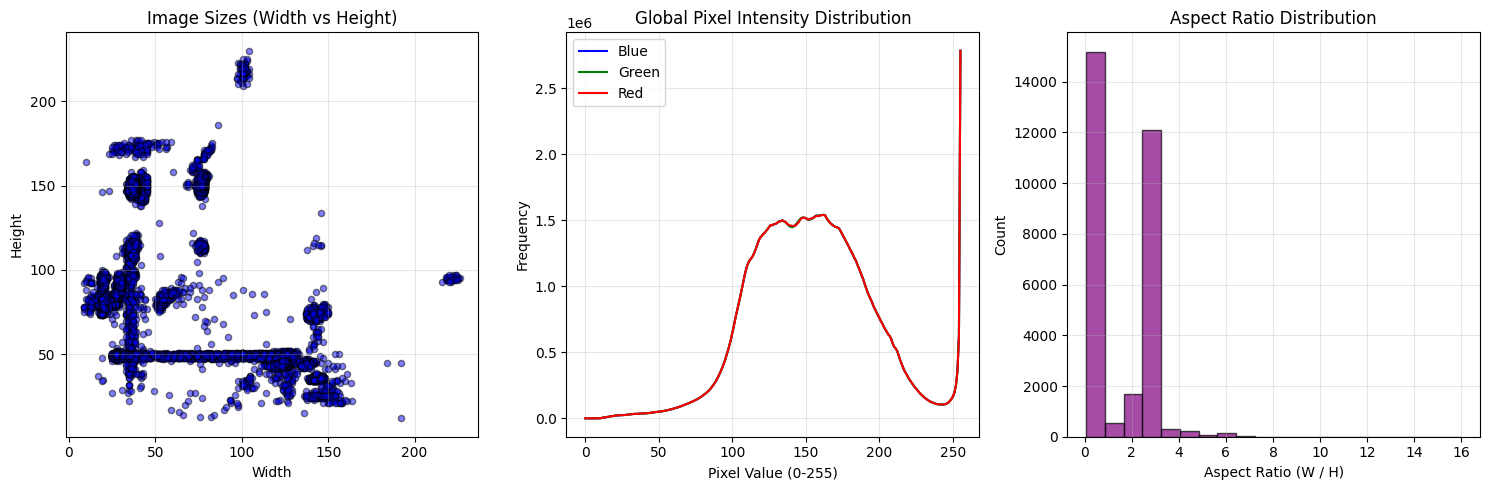

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

def analyze_dl_dataset(dataset_path, size_tolerance=0.05, sample_ratio=1.0):
    """
    Groups images by size and analyzes pixel distribution.
    
    Args:
        dataset_path (str): Path to folder containing images.
        size_tolerance (float): Percentage margin (0.05 = 5%) to group similar sizes.
        sample_ratio (float): If dataset is huge, use 0.1 to analyze only 10% of images for speed.
    """
    
    image_paths = []
    # 1. Collect all image paths
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif')
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))

    if not image_paths:
        print("No images found!")
        return

    print(f"Found {len(image_paths)} images. Analyzing...")

    # Data structures
    size_groups = defaultdict(list) # Key: (W, H), Value: list of paths
    widths = []
    heights = []
    
    # Pixel stats accumulators
    channel_sum = np.zeros(3)
    channel_sq_sum = np.zeros(3)
    pixel_count = 0
    
    # For histogram (Global)
    hist_bins = np.zeros((256, 3)) # Bins for B, G, R

    # 2. Iterate and Process
    # We use a stride to sample if dataset is too large
    step = int(1 / sample_ratio)
    
    for img_path in tqdm(image_paths[::step]):
        # Read Image
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h, w, c = img.shape
        widths.append(w)
        heights.append(h)

        # --- Grouping Logic ---
        # We try to find an existing group that fits within the tolerance
        found_group = False
        for (gw, gh) in size_groups.keys():
            # Check if current image is within +/- tolerance of group key
            w_margin = gw * size_tolerance
            h_margin = gh * size_tolerance
            
            if (gw - w_margin <= w <= gw + w_margin) and (gh - h_margin <= h <= gh + h_margin):
                size_groups[(gw, gh)].append(img_path)
                found_group = True
                break
        
        if not found_group:
            size_groups[(w, h)].append(img_path)

        # --- Pixel Analysis (Mean/Std & Hist) ---
        # Normalize to 0-1 for standard calculations often used in PyTorch/TF
        img_norm = img / 255.0
        
        # Add to mean/std accumulators
        channel_sum += np.sum(img_norm, axis=(0, 1))
        channel_sq_sum += np.sum(img_norm ** 2, axis=(0, 1))
        pixel_count += (w * h)

        # Calculate Histogram (accumulate raw counts)
        for i, color in enumerate(['b', 'g', 'r']):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            hist_bins[:, i] += hist.flatten()

    # 3. Final Calculations
    # Mean and Std Dev
    mean = channel_sum / pixel_count
    # Std = sqrt( E[x^2] - (E[x])^2 )
    std = np.sqrt((channel_sq_sum / pixel_count) - (mean ** 2))
    
    # Reverse BGR to RGB for reporting
    mean_rgb = mean[::-1]
    std_rgb = std[::-1]

    # 4. Reporting & Visualization
    print("\n" + "="*40)
    print(" 📊 DATASET ANALYSIS REPORT")
    print("="*40)
    print(f"Total Images Analyzed: {len(widths)}")
    print(f"Resolution Groups Found: {len(size_groups)} (Tolerance: {size_tolerance*100}%)")
    print("-" * 20)
    print(f"Global Mean (RGB): [{mean_rgb[0]:.4f}, {mean_rgb[1]:.4f}, {mean_rgb[2]:.4f}]")
    print(f"Global Std  (RGB): [{std_rgb[0]:.4f}, {std_rgb[1]:.4f}, {std_rgb[2]:.4f}]")
    print("-" * 20)
    
    # Top 5 Groups
    sorted_groups = sorted(size_groups.items(), key=lambda x: len(x[1]), reverse=True)
    print("Top 5 Image Sizes (Approx):")
    for (w, h), paths in sorted_groups[:5]:
        print(f"  - {w}x{h} : {len(paths)} images")

    # --- PLOTTING ---
    plt.figure(figsize=(15, 5))

    # Plot 1: Width vs Height Scatter (Aspect Ratio visualization)
    plt.subplot(1, 3, 1)
    plt.scatter(widths,heights, alpha=0.5, c='blue', edgecolors='k', s=20)
    plt.title("Image Sizes (Width vs Height)")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.grid(True, alpha=0.3)

    # Plot 2: Pixel Intensity Histogram
    plt.subplot(1, 3, 2)
    colors = ('b', 'g', 'r')
    labels = ('Blue', 'Green', 'Red')
    for i, color in enumerate(colors):
        plt.plot(hist_bins[:, i], color=color, label=labels[i])
    plt.title("Global Pixel Intensity Distribution")
    plt.xlabel("Pixel Value (0-255)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Aspect Ratio Distribution
    plt.subplot(1, 3, 3)
    aspect_ratios = np.array(widths) / np.array(heights)
    plt.hist(aspect_ratios, bins=20, color='purple', edgecolor='black', alpha=0.7)
    plt.title("Aspect Ratio Distribution")
    plt.xlabel("Aspect Ratio (W / H)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Replace with your folder path
analyze_dl_dataset(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells_temp\temp test\healthy", size_tolerance=0.10)

In [19]:
import os
import shutil
import cv2
from tqdm import tqdm

def isolate_images_by_size(src_folder, dest_folder, tolerance=0.1, action='copy'):
    """
    Groups images by size and moves/copies them into subfolders.
    
    Args:
        src_folder (str): Source directory containing images.
        dest_folder (str): Destination directory where groups will be created.
        tolerance (float): Margin of error (0.05 = 5%).
        action (str): 'copy' to keep originals, 'move' to delete originals.
    """
    
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
        
    # Supported extensions
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    
    # Dictionary to store group definitions: 
    # Key: (Reference Width, Reference Height), Value: Folder Name
    active_groups = {} 
    
    print(f"Scanning '{src_folder}'...")
    
    # 1. Walk through source folder
    files_to_process = []
    for root, _, files in os.walk(src_folder):
        for file in files:
            if file.lower().endswith(valid_exts):
                files_to_process.append(os.path.join(root, file))
    
    print(f"Found {len(files_to_process)} images. Starting isolation ({action})...")
    
    # 2. Process each image
    for img_path in tqdm(files_to_process):
        # Read image just to get dims (load as header only would be faster, but cv2 needs load)
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h, w = img.shape[:2]
        
        # 3. Find a matching group
        target_group_folder = None
        
        for (ref_w, ref_h), folder_name in active_groups.items():
            # Calculate margins
            w_margin = ref_w * tolerance
            h_margin = ref_h * tolerance
            
            # Check if current image fits in this group
            if (ref_w - w_margin <= w <= ref_w + w_margin) and \
               (ref_h - h_margin <= h <= ref_h + h_margin):
                target_group_folder = folder_name
                break
        
        # 4. If no group found, create a new one
        if target_group_folder is None:
            folder_name = f"size_{w}x{h}"
            active_groups[(w, h)] = folder_name
            target_group_folder = folder_name
            
        # 5. Perform the Move/Copy
        full_dest_path = os.path.join(dest_folder, target_group_folder)
        if not os.path.exists(full_dest_path):
            os.makedirs(full_dest_path)
            
        # Handle duplicate filenames (e.g., img1.jpg from two different source folders)
        filename = os.path.basename(img_path)
        final_path = os.path.join(full_dest_path, filename)
        
        counter = 1
        while os.path.exists(final_path):
            name, ext = os.path.splitext(filename)
            final_path = os.path.join(full_dest_path, f"{name}_{counter}{ext}")
            counter += 1
            
        if action == 'move':
            shutil.move(img_path, final_path)
        else:
            shutil.copy2(img_path, final_path)

    print("\n" + "="*30)
    print("Done! Summary of Groups:")
    print("="*30)
    for (w, h), folder in active_groups.items():
        count = len(os.listdir(os.path.join(dest_folder, folder)))
        print(f"📁 {folder:<20} : {count} images (Ref: {w}x{h})")

# --- USAGE ---
# Change paths below
source = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells_temp\temp test\healthy"
source = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\micro_crack"
destination = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells_healthy_groups"
destination = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\micro_crack_isolated"

# tolerance=0.05 means 100x100 and 105x95 will go in same folder
# action='copy' is safer than 'move'
isolate_images_by_size(source, destination, tolerance=0.15, action='copy')

Scanning 'C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\micro_crack'...
Found 504 images. Starting isolation (copy)...


100%|██████████| 504/504 [00:00<00:00, 1352.10it/s]


Done! Summary of Groups:
📁 size_76x151          : 126 images (Ref: 76x151)
📁 size_36x148          : 70 images (Ref: 36x148)
📁 size_146x73          : 37 images (Ref: 146x73)
📁 size_42x51           : 17 images (Ref: 42x51)
📁 size_28x50           : 111 images (Ref: 28x50)
📁 size_103x75          : 1 images (Ref: 103x75)
📁 size_114x50          : 72 images (Ref: 114x50)
📁 size_35x51           : 10 images (Ref: 35x51)
📁 size_144x37          : 10 images (Ref: 144x37)
📁 size_53x50           : 13 images (Ref: 53x50)
📁 size_82x49           : 18 images (Ref: 82x49)
📁 size_78x177          : 3 images (Ref: 78x177)
📁 size_91x225          : 3 images (Ref: 91x225)
📁 size_89x146          : 1 images (Ref: 89x146)
📁 size_76x115          : 1 images (Ref: 76x115)
📁 size_69x49           : 4 images (Ref: 69x49)
📁 size_26x63           : 1 images (Ref: 26x63)
📁 size_95x50           : 3 images (Ref: 95x50)
📁 size_138x45          : 3 images (Ref: 138x45)


In [18]:
base= r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells_healthy_groups"
images_dir = (os.listdir(base+"\group_30x"))
# images_dir.extend(os.listdir(base+"\group_20x"))
# images_dir.extend(os.listdir(base+"\group_30x"))

full_dest_path = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\dataset_cropped_cells_healthy_groups\final selected group"

for im_path in images_dir:
    img_path = base + "\group_30x\\" + im_path
    filename = os.path.basename(img_path)
    final_path = os.path.join(full_dest_path, filename)
    shutil.copy2(img_path, final_path)

detecting pvs first 

In [20]:
MODEL_PATH = r'runs\detect\train20\weights\best.pt'

In [23]:
from ultralytics import YOLO

In [24]:
model = YOLO(MODEL_PATH)

In [25]:
results = model.predict(source=r"C:\Users\Rowan\Documents\Rowan\all clean", classes=[0], conf=0.25, save=True, name=r"C:\Users\Rowan\Documents\Rowan\Yolo_test\pv det from image using yolo\PV det")


image 1/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0496.JPG: 384x640 2 examineds, 30.1ms
image 2/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0531.JPG: 384x640 1 examined, 8.8ms
image 3/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0678.JPG: 384x640 (no detections), 8.8ms
image 4/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0791.JPG: 448x640 (no detections), 37.2ms
image 5/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0833.JPG: 448x640 (no detections), 9.8ms
image 6/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0848.JPG: 448x640 (no detections), 9.2ms
image 7/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0948.JPG: 384x640 (no detections), 9.9ms
image 8/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_1273.JPG: 640x448 (no detections), 25.3ms
image 9/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_1315.JPG: 640x448 (no detections), 10.2ms
image 10/42 C:\Users\Rowan\Documents\Rowan\all clean\DSC_1335.JPG: 640x448 (no detections), 9.7ms
image 11/42 C:\Users\Rowan\Docume

In [2]:
import os

base_clean = r"C:\Users\Rowan\Documents\Rowan\all clean\\"
images_path = os.listdir(base_clean)

In [3]:
from ultralytics import FastSAM
# from ultralytics.models.fastsam import FastSAMPrompt

model = FastSAM('FastSAM-s.pt')  # Smallest model (fastest)

# Run on your image
results = model(base_clean + images_path[0], device='cpu', conf=0.5, iou=0.5)

# Prompt it to find the panel
# You can simply ask it to find the largest contour or prompt with text
# prompt_process = FastSAMPrompt(base_clean + images_path[0], results, device='cpu')
# ann = prompt_process.text_prompt(text='solar panel')

# 'ann' is your mask. Use cv2.findContours on this mask to get corners.


image 1/1 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0496.JPG: 384x640 4 objects, 104.4ms
Speed: 3.1ms preprocess, 104.4ms inference, 8.2ms postprocess per image at shape (1, 3, 384, 640)


In [13]:
# from ultralytics.models.fastsam import FastSAMPredictor

# # Create FastSAMPredictor
# overrides = dict(conf=0.25, task="segment", mode="predict", device='cpu', model="FastSAM-s.pt", save=False, imgsz=1024)
# predictor = FastSAMPredictor(overrides=overrides)

# # Segment everything
# everything_results = predictor(base_clean + images_path[0])

# # Prompt inference
# bbox_results = predictor.prompt(everything_results, bboxes=[[200, 200, 300, 300]])
# point_results = predictor.prompt(everything_results, points=[200, 200])

In [ ]:
result = ann[0]

# Returns a list of arrays; each array is the [x, y] boundary of one object
masks_contours = result.masks.xy 

# Example: Print the first point of the first detected mask
print(masks_contours[0][0])

# Returns a PyTorch Tensor of shape (N, H, W)
# N = Number of objects detected
masks_tensor = result.masks.data

# Convert to standard Numpy array for OpenCV usage
import numpy as np
masks_np = result.masks.data.cpu().numpy()

# Example: Get the mask for the first object
first_mask = masks_np[0] # This is a 2D boolean array (0 or 1)

result = ann[0]

boxes = result.boxes

for box in boxes:
    # Get coordinates (x1, y1, x2, y2)
    coords = box.xyxy[0].cpu().numpy()
    
    # Get confidence score
    conf = box.conf[0].item()
    
    # Get class ID (FastSAM usually just returns class 0 for everything)
    cls = int(box.cls[0].item())
    
    print(f"Box: {coords}, Conf: {conf}")

# Plot the results (draws masks and boxes on the image)
annotated_img = result.plot()

# Save or show using OpenCV
import cv2
cv2.imwrite("output.jpg", annotated_img)
# cv2.imshow("Result", annotated_img)
# cv2.waitKey(0)

[     1936.4       225.6]
Box: [          0           0        6016        3384], Conf: 0.9601791501045227


True

In [12]:
# from ultralytics.models.fastsam import FastSAMPrompt
from ultralytics.models.fastsam import FastSAMPredictor

for i, img in enumerate(images_path):
    # 1. Run inference
    results = model(base_clean + img)

    # 2. Attach the prompt processor
    # prompt_process = FastSAMPrompt(base_clean + img, results, device='cpu')

    overrides = dict(conf=0.25, task="segment", mode="predict", device='cpu', model="FastSAM-s.pt", save=False, imgsz=640)
    predictor = FastSAMPredictor(overrides=overrides)

    # Segment everything
    everything_results = predictor(base_clean + img)

    # 3. Apply a prompt (Text, Box, or Point)
    # Text Prompt
    ann = predictor.prompt(everything_results, texts='solar panels')
    
    result = ann[0]

    boxes = result.boxes

    for box in boxes:
        # Get coordinates (x1, y1, x2, y2)
        coords = box.xyxy[0].cpu().numpy()
        
        # Get confidence score
        conf = box.conf[0].item()
        
        # Get class ID (FastSAM usually just returns class 0 for everything)
        cls = int(box.cls[0].item())
        
        print(f"Box: {coords}, Conf: {conf}")

    # Plot the results (draws masks and boxes on the image)
    annotated_img = result.plot()

    # Save or show using OpenCV
    import cv2
    cv2.imwrite(f"C:/Users/Rowan/Documents/Rowan/Yolo_test/pv det from image using yolo/PV det/output_{i}.jpg", annotated_img)

# Box Prompt [x1, y1, x2, y2]
# ann = prompt_process.box_prompt(bbox=[100, 100, 200, 200])

# 4. Plot the specific result
# predictor.plots(annotations=ann, output='./prompt_output.jpg')


image 1/1 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0496.JPG: 384x640 6 objects, 96.2ms
Speed: 2.4ms preprocess, 96.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CPU (Intel Core i7-14700F)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0496.JPG: 640x640 6 objects, 82.6ms
Speed: 2.4ms preprocess, 82.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Box: [          0           0        6016        3384], Conf: 0.9601791501045227

image 1/1 C:\Users\Rowan\Documents\Rowan\all clean\DSC_0531.JPG: 384x640 21 objects, 102.9ms
Speed: 1.4ms preprocess, 102.9ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CPU (Intel Core i7-14700F)
YOLOv8s-seg summary (fused): 85 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
image 1/1 C:

In [ ]:

import cv2
import os
import numpy as np
from ultralytics import YOLO

# --- CONFIGURATION ---
CELL_MODEL_PATH = r'runs\detect\train54\weights\best.pt'   # Your model that detects cells (0 or 1)
IMAGES_DIR = r'modified_mixed_pv_orig_res\train'       # Folder with raw drone images
GLOBAL_LABELS_DIR = r'modified_mixed_pv_orig_res\train' # Folder with defect labels for the WHOLE image
OUTPUT_DIR = 'mixed_dataset/training_crops'  # Where to save new data
MARGIN = 0.10                       # 10% margin to handle warped edges

# Create directories
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels", exist_ok=True)

# Load Cell Model
model = YOLO(CELL_MODEL_PATH)

def denormalize(coords, w_img, h_img):
    # Convert YOLO (xc, yc, w, h) to Pixels (x1, y1, x2, y2)
    xc, yc, w, h = coords
    x1 = int((xc - w/2) * w_img)
    y1 = int((yc - h/2) * h_img)
    x2 = int((xc + w/2) * w_img)
    y2 = int((yc + h/2) * h_img)
    return [x1, y1, x2, y2]

def normalize(box, w_crop, h_crop):
    # Convert Pixels (x1, y1, x2, y2) to YOLO (xc, yc, w, h)
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    xc = x1 + w/2
    yc = y1 + h/2
    return [xc/w_crop, yc/h_crop, w/w_crop, h/h_crop]

# Process every image
image_files = []

# print(img_file)
for img_file in image_files:
    # 1. Load Image
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path)
    h_img, w_img = img.shape[:2]
    
    # 2. Load Global Defect Labels
    label_file = img_file.rsplit('.', 1) + '.txt'
    global_label_path = os.path.join(GLOBAL_LABELS_DIR, label_file)
    global_defects = []
    if os.path.exists(global_label_path):
        with open(global_label_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                cls = int(parts)
                # Store class and pixel coords [cls, x1, y1, x2, y2]
                pixel_box = denormalize(parts[1:], w_img, h_img)
                global_defects.append([cls] + pixel_box)
    print(os.path.exists(global_label_path))
    # 3. Detect Cells (Using simple inference, swap with SAHI code above if merging persists)
    results = model.predict(img_path, conf=0.25, verbose=False)
    print(results)
    for i, cell_box in enumerate(results.boxes.xyxy.cpu().numpy()):
        # cell_box is [x1, y1, x2, y2]
        cx1, cy1, cx2, cy2 = cell_box
        
        # Apply Margin
        cw, ch = cx2 - cx1, cy2 - cy1
        cx1 = max(0, int(cx1 - cw * MARGIN))
        cy1 = max(0, int(cy1 - ch * MARGIN))
        cx2 = min(w_img, int(cx2 + cw * MARGIN))
        cy2 = min(h_img, int(cy2 + ch * MARGIN))
        
        crop_w = cx2 - cx1
        crop_h = cy2 - cy1
        
        # Crop the Cell
        crop_img = img[cy1:cy2, cx1:cx2]
        
        # 4. Find Overlapping Defects
        local_labels = []
        for defect in global_defects:
            d_cls, dx1, dy1, dx2, dy2 = defect
            
            # Calculate Intersection
            ix1 = max(cx1, dx1)
            iy1 = max(cy1, dy1)
            ix2 = min(cx2, dx2)
            iy2 = min(cy2, dy2)
            
            # Check if there is a valid intersection
            if ix2 > ix1 and iy2 > iy1:
                # Calculate Intersection Area vs Defect Area
                inter_area = (ix2 - ix1) * (iy2 - iy1)
                defect_area = (dx2 - dx1) * (dy2 - dy1)
                
                # Rule: Only keep defect if >30% of it is inside this cell crop
                # This prevents tiny slivers from neighbors being labeled
                if (inter_area / defect_area) > 0.3:
                    # Shift coordinates to be relative to the Crop (Local Frame)
                    lx1 = ix1 - cx1
                    ly1 = iy1 - cy1
                    lx2 = ix2 - cx1
                    ly2 = iy2 - cy1
                    
                    # Convert to YOLO format
                    yolo_label = normalize([lx1, ly1, lx2, ly2], crop_w, crop_h)
                    local_labels.append([d_cls] + yolo_label)
        
        # 5. Save Crop and New Labels
        # Only save if labels exist (unless you want negative samples too)
        if local_labels: 
            save_name = f"{img_file.rsplit('.', 1)}_cell_{i}"
            cv2.imwrite(f"{OUTPUT_DIR}/images/{save_name}.jpg", crop_img)
            
            with open(f"{OUTPUT_DIR}/labels/{save_name}.txt", 'w') as f:
                for lbl in local_labels:
                    f.write(f"{int(lbl)} {' '.join(map(str, lbl[1:]))}\n")

print("Processing complete. Ready for training.")

Processing complete. Ready for training.


In [19]:
import cv2
import os
import numpy as np
from ultralytics import YOLO

# --- CONFIGURATION ---
CELL_MODEL_PATH = r'runs\detect\train54\weights\best.pt'   # Your model that detects cells (0 or 1)
IMAGES_DIR = r'modified_mixed_pv_orig_res\valid\images'       # Folder with raw drone images
GLOBAL_LABELS_DIR = r'modified_mixed_pv_orig_res\valid\labels' # Folder with defect labels for the WHOLE image
OUTPUT_DIR = 'mixed_dataset/validing_crops'  # Where to save new data

MARGIN = 0.1                            # 10% margin to capture warped edges

# Create directories
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/labels", exist_ok=True)

model = YOLO(CELL_MODEL_PATH)

def denormalize(coords, w_img, h_img):
    # Convert YOLO (xc, yc, w, h) to Pixel Corners (x1, y1, x2, y2)
    xc, yc, w, h = coords
    x1 = int((xc - w/2) * w_img)
    y1 = int((yc - h/2) * h_img)
    x2 = int((xc + w/2) * w_img)
    y2 = int((yc + h/2) * h_img)
    return [x1, y1, x2, y2]

def normalize(box, w_crop, h_crop):
    # Convert Pixel Corners (x1, y1, x2, y2) to YOLO (xc, yc, w, h)
    x1, y1, x2, y2 = box
    w = x2 - x1
    h = y2 - y1
    xc = x1 + w/2
    yc = y1 + h/2
    return [xc/w_crop, yc/h_crop, w/w_crop, h/h_crop]

# Process Images

for img_file in os.listdir(IMAGES_DIR):
    if not img_file.endswith(('.jpg', '.png')): continue
    
    # 1. Load Image and Dimensions
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path)
    h_img, w_img = img.shape[:2]
    
    # 2. Load Global Defect Labels (if they exist)
    global_defects = []
    
    label_path = os.path.join(GLOBAL_LABELS_DIR, img_file.rsplit('.', 1)[0] + '.txt')
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                cls = int(parts[0])
                # Convert to pixel coordinates for calculation
                pixel_box = denormalize(parts[1:], w_img, h_img)
                global_defects.append({'cls': cls, 'box': pixel_box})

    # 3. Detect Cells (Using Sliced Inference is recommended here too!)
    # For simplicity, using standard predict here, but swap with SAHI if needed
    results = model.predict(img_path, conf=0.25, verbose=False)
    
    for i, cell_box in enumerate(results[0].boxes.xyxy.cpu().numpy()):
        cx1, cy1, cx2, cy2 = map(int, cell_box)
        
        # Apply Margin (Expand the crop)
        w_cell = cx2 - cx1
        h_cell = cy2 - cy1
        cx1 = max(0, int(cx1 - w_cell * MARGIN))
        cy1 = max(0, int(cy1 - h_cell * MARGIN))
        cx2 = min(w_img, int(cx2 + w_cell * MARGIN))
        cy2 = min(h_img, int(cy2 + h_cell * MARGIN))
        
        # Crop
        crop_img = img[cy1:cy2, cx1:cx2]
        h_crop, w_crop = crop_img.shape[:2]
        
        # 4. Find Defects Inside This Cell
        local_labels = []
        for defect in global_defects:
            d_cls = defect['cls']
            dx1, dy1, dx2, dy2 = defect['box']
            
            # Intersection (clipping defect to the cell crop)
            ix1 = max(cx1, dx1)
            iy1 = max(cy1, dy1)
            ix2 = min(cx2, dx2)
            iy2 = min(cy2, dy2)
            
            # If intersection is valid and covers a significant part of the defect
            if ix2 > ix1 and iy2 > iy1:
                inter_area = (ix2 - ix1) * (iy2 - iy1)
                defect_area = (dx2 - dx1) * (dy2 - dy1)
                
                # Threshold: Defect must be at least 30% visible in this crop
                if (inter_area / defect_area) > 0.3:
                    # Convert Global Pixels -> Local Crop Pixels
                    lx1 = ix1 - cx1
                    ly1 = iy1 - cy1
                    lx2 = ix2 - cx1
                    ly2 = iy2 - cy1
                    # Normalize to YOLO format (0-1)
                    yolo_label = normalize([lx1, ly1, lx2, ly2], w_crop, h_crop)
                    local_labels.append([d_cls] + yolo_label)
        
        # 5. Save if valid
        # Saves the crop image and the new.txt label file
        save_base = f"{img_file.rsplit('.', 1)[0]}_cell_{i}"
        cv2.imwrite(f"{OUTPUT_DIR}/images/{save_base}.jpg", crop_img)
        
        if local_labels:
            with open(f"{OUTPUT_DIR}/labels/{save_base}.txt", 'w') as f:
                for lbl in local_labels:
                    f.write(f"{int(lbl[0])} {' '.join(map(str, lbl[1:]))}\n")

print("Pipeline Complete. Train your defect model on 'data/dataset_crops'")

Pipeline Complete. Train your defect model on 'data/dataset_crops'


In [ ]:
# crop from 2000px original resolution and upscale cropped

## to be in script code

In [1]:


from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=r"cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml",
    epochs=50,
    imgsz=320,
    
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    box=7.5,  # Increase box loss weight
    cls=0.5,  # Decrease cls loss if classes are imbalanced
    dfl=1.5,
    # fl_gamma=1.5,  # Focal loss
    mosaic=0.5,
    mixup=0.1,
    copy_paste=0.5,  # If available
    workers=2,
    
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_sc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000192B2316620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

In [4]:
from ultralytics import YOLO

model = YOLO(r"final_env_yolo\Lib\site-packages\ultralytics\cfg\models\v8\yolov8m-p2.yaml")

model.train(
    data=r"cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml",
    epochs=60,
    imgsz=320,
    
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    box=7.5,  # Increase box loss weight
    cls=0.5,  # Decrease cls loss if classes are imbalanced
    dfl=1.5,
    # fl_gamma=1.5,  # Focal loss
    mosaic=0.5,
    mixup=0.1,
    copy_paste=0.5,  # If available
    workers=2,
    
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=final_env_yolo\Lib\site-packages\ultralytics\cfg\

KeyboardInterrupt: 

In [5]:
# with changed yolo augment . so return to linear in final_env_yolo\Lib\site-packages\ultralytics\data\augment.py

from ultralytics import YOLO

model = YOLO(r"final_env_yolo\Lib\site-packages\ultralytics\cfg\models\v8\yolov8m-p2.yaml")

model.train(

    data=r"cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml",
    epochs=60,
    imgsz=640,
    batch=8,
    # lr0=0.01,
    # lrf=0.01,

    warmup_epochs=3,
    box=7.5,  # Increase box loss weight
    cls=0.5,  # Decrease cls loss if classes are imbalanced
    dfl=1.5,
    # fl_gamma=1.5,  # Focal loss
    mosaic=0.0,
    mixup=0.1,
    copy_paste=0.5,  # If available
    # workers=2,
    
    patience=15,
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=final_env_yolo\Lib\site-packages\ultralytics\cfg\m

Traceback (most recent call last):
  File "C:\Program Files\Python310\lib\multiprocessing\queues.py", line 247, in _feed
    send_bytes(obj)
  File "C:\Program Files\Python310\lib\multiprocessing\connection.py", line 205, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Program Files\Python310\lib\multiprocessing\connection.py", line 285, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed


KeyboardInterrupt: 

In [ ]:


from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=r"cell_separation_from_mixed_orig\final_yolo_datasets\vendor_2\data.yaml",
    epochs=60,
    imgsz=320,
    
    lr0=0.01,
    lrf=0.01,
    warmup_epochs=3,
    box=7.5,  # Increase box loss weight
    cls=0.5,  # Decrease cls loss if classes are imbalanced
    dfl=1.5,
    
    mosaic=0.0,
    mixup=0.1,
    copy_paste=0.5,  # If available
    workers=2,
    
    patience=15,
)

In [2]:
import os

In [10]:
new_images = os.listdir(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\some_new_healthy_for_test")
old_health = os.listdir(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\some_healthy_from_mixed_after_yolo8s")

In [11]:
set(new_images) & set(old_health)

{'0image-3-_jpg.rf.34a4425a9bfee178d324d723a9fdb6f0_cell29.jpg',
 '15image-2-_jpg.rf.f35b7227e91df9b0f20aae4a79b1966a_cell35.jpg',
 '45-163-_jpg.rf.90a400d822c747f171561f979d970cc1_cell13.jpg',
 '45-163-_jpg.rf.90a400d822c747f171561f979d970cc1_cell20.jpg',
 '45-167-_jpg.rf.de5b48940ecbf73d5e30a62350b59c34_cell20.jpg'}

In [ ]:
# moved banalce to yolo_rpreprocessin

In [2]:
for subset in ["train", "valid", "test"]:
    balance_folder(subset)


--- Processing 'train' set ---
Found: 23897 Defects | 168622 Backgrounds
⚠️ Imbalance detected! Keeping 4779 backgrounds, removing 163843...


Moving files: 100%|██████████| 163843/163843 [04:35<00:00, 594.58it/s]


✅ Done. Excess files moved to: modified_mixed_pv_orig_res_final_for_integ_more_cls\removed_excess_backgrounds\train

--- Processing 'valid' set ---
Found: 6714 Defects | 52092 Backgrounds
⚠️ Imbalance detected! Keeping 1342 backgrounds, removing 50750...


Moving files: 100%|██████████| 50750/50750 [01:02<00:00, 813.90it/s] 


✅ Done. Excess files moved to: modified_mixed_pv_orig_res_final_for_integ_more_cls\removed_excess_backgrounds\valid

--- Processing 'test' set ---
Found: 3160 Defects | 21374 Backgrounds
⚠️ Imbalance detected! Keeping 632 backgrounds, removing 20742...


Moving files: 100%|██████████| 20742/20742 [00:22<00:00, 915.32it/s] 

✅ Done. Excess files moved to: modified_mixed_pv_orig_res_final_for_integ_more_cls\removed_excess_backgrounds\test


In [3]:
for split in ["train", "valid", "test"]:
    images_dir = f"pv_mixed_crop_orig_res_final_for_integ_more_cls/{split}/images"
    labels_dir = f"pv_mixed_crop_orig_res_final_for_integ_more_cls/{split}/labels"

    if not os.path.exists(images_dir):
        continue

    image_files = {
        os.path.splitext(f)[0]
        for f in os.listdir(images_dir)
    }

    for label_file in os.listdir(labels_dir):
        if label_file.endswith(".txt"):
            if os.path.splitext(label_file)[0] not in image_files:
                print("willl remove",  label_file)
                os.remove(os.path.join(labels_dir, label_file))

willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell114.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell119.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell120.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell121.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell132.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell19.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell24.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell44.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell45.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell78.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell91.txt
willl remove 000007_png.rf.0d41090a31cd1f2da0bbe07e6e7b2310_cell93.txt
willl remove 000012_png.rf.840c4db3304d54600116954f9fa996af_cell11.txt
willl remove 000012_png.rf.840c4db3304d54600116954f9fa996af_cell2.txt
wi